**Loading the Datafile and displaying the header values**

In [1]:
import pandas as pd

# Replace with your file name
df = pd.read_csv("/content/Online Sales Data.csv")

df.head()

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


**Getting the basic information from the data**





In [2]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)

df.info()
df.describe()

Shape: (240, 9)

Columns: Index(['Transaction ID', 'Date', 'Product Category', 'Product Name',
       'Units Sold', 'Unit Price', 'Total Revenue', 'Region',
       'Payment Method'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    240 non-null    int64  
 1   Date              240 non-null    object 
 2   Product Category  240 non-null    object 
 3   Product Name      240 non-null    object 
 4   Units Sold        240 non-null    int64  
 5   Unit Price        240 non-null    float64
 6   Total Revenue     240 non-null    float64
 7   Region            240 non-null    object 
 8   Payment Method    240 non-null    object 
dtypes: float64(2), int64(2), object(5)
memory usage: 17.0+ KB


,Transaction ID,Units Sold,Unit Price,Total Revenue
count,240.00000,240.000000,240.000000,240.000000
mean,10120.50000,2.158333,236.395583,335.699375
std,69.42622,1.322454,429.446695,485.804469
min,10001.00000,1.000000,6.500000,6.500000
25%,10060.75000,1.000000,29.500000,62.965000
50%,10120.50000,2.000000,89.990000,179.970000
75%,10180.25000,3.000000,249.990000,399.225000
max,10240.00000,10.000000,3899.990000,3899.990000


**Creating Dictionary for the dataset**

In [3]:
data_dict = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.notnull().sum().values,
    "Unique Values": df.nunique().values
})

data_dict

,Column Name,Data Type,Non-Null Count,Unique Values
0,Transaction ID,int64,240,240
1,Date,object,240,240
2,Product Category,object,240,6
3,Product Name,object,240,232
4,Units Sold,int64,240,7
5,Unit Price,float64,240,117
6,Total Revenue,float64,240,173
7,Region,object,240,3
8,Payment Method,object,240,3


**Cheking the missing values**

In [4]:
#To check missing values
df.isnull().sum()

,0
Transaction ID,0
Date,0
Product Category,0
Product Name,0
Units Sold,0
Unit Price,0
Total Revenue,0
Region,0
Payment Method,0


**Checking duplicates**

In [5]:
df.duplicated().sum()

np.int64(0)

**Cleaning the dataset**

In [7]:
#Duplicates
df = df.drop_duplicates()

#Missing values
df['Product Category'].fillna('Unknown', inplace=True)
df['Product Name'].fillna('Unknown', inplace=True)
df['Region'].fillna('Unknown', inplace=True)
df['Payment Method'].fillna('Unknown', inplace=True)

df['Units Sold'].fillna(df['Units Sold'].mean(), inplace=True)
df['Unit Price'].fillna(df['Unit Price'].mean(), inplace=True)
df['Total Revenue'].fillna(df['Total Revenue'].mean(), inplace=True)

#Date Format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

#Text columns
text_cols = ['Product Category', 'Product Name', 'Region', 'Payment Method']

for col in text_cols:
    df[col] = df[col].str.lower().str.strip()

/tmp/ipykernel_10087/1152788237.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Product Category'].fillna('Unknown', inplace=True)
/tmp/ipykernel_10087/1152788237.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

**Feature Engineering**

In [8]:
#Time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

#Verifying revenue
df['Calculated Revenue'] = df['Units Sold'] * df['Unit Price']

#Checking revenue difference
df['Revenue Difference'] = df['Total Revenue'] - df['Calculated Revenue']

**Checking the outliers**

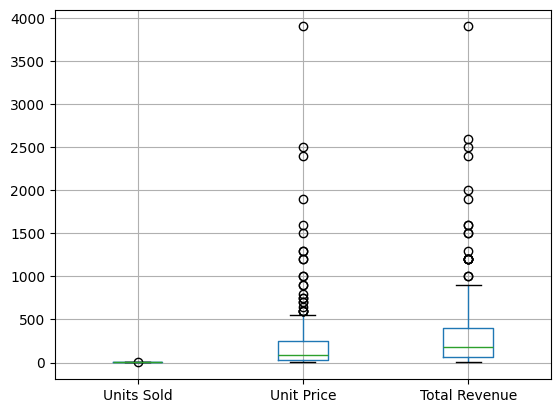

In [9]:
import matplotlib.pyplot as plt

df[['Units Sold','Unit Price','Total Revenue']].boxplot()
plt.show()

In [10]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction ID      240 non-null    int64         
 1   Date                240 non-null    datetime64[ns]
 2   Product Category    240 non-null    object        
 3   Product Name        240 non-null    object        
 4   Units Sold          240 non-null    int64         
 5   Unit Price          240 non-null    float64       
 6   Total Revenue       240 non-null    float64       
 7   Region              240 non-null    object        
 8   Payment Method      240 non-null    object        
 9   Year                240 non-null    int32         
 10  Month               240 non-null    int32         
 11  Day                 240 non-null    int32         
 12  Calculated Revenue  240 non-null    float64       
 13  Revenue Difference  240 non-null    float64       

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method,Year,Month,Day,Calculated Revenue,Revenue Difference
0,10001,2024-01-01,electronics,iphone 14 pro,2,999.99,1999.98,north america,credit card,2024,1,1,1999.98,0.000000e+00
1,10002,2024-01-02,home appliances,dyson v11 vacuum,1,499.99,499.99,europe,paypal,2024,1,2,499.99,0.000000e+00
2,10003,2024-01-03,clothing,levi's 501 jeans,3,69.99,209.97,asia,debit card,2024,1,3,209.97,2.842171e-14
3,10004,2024-01-04,books,the da vinci code,4,15.99,63.96,north america,credit card,2024,1,4,63.96,0.000000e+00
4,10005,2024-01-05,beauty products,neutrogena skincare set,1,89.99,89.99,europe,paypal,2024,1,5,89.99,0.000000e+00


**Getting the cleaned dataset**

In [11]:
df.to_csv("cleaned_sales_data.csv", index=False)
data_dict.to_csv("data_dictionary.csv", index=False)